In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from os.path import join
import os

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id,download_dir
add_to_path(join(root_dir, 'src'))
import utils.preprocessing as preprocessing
import anomaly_detection.deep_learning.AE as AE
from data_loader import load_data

Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [3]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

len(list_session)

40

In [4]:
# We only keep normal sessions
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

clean_sessions = [
    k for k in list_session
    if os.path.splitext(os.path.basename(k))[0] not in session_anomaly
]
df_list = []

for cle in clean_sessions:
    df_temp = data_dict[cle].copy()
    df_temp = preprocessing.clean_dataframe(df_temp)
    session_name = os.path.splitext(os.path.basename(cle))[0]
    if 'session_id' not in df_temp.columns:
        df_temp['session_id'] = session_name
    df_list.append(df_temp)

df_filtered = pd.concat(df_list, ignore_index=True)


print(f"Données chargées. Dimensions : {df_filtered.shape}")
print(f"Nombre de sessions saines : {df_filtered['session_id'].nunique()}")
display(df_filtered.head())


Données chargées. Dimensions : (289405, 18)
Nombre de sessions saines : 30


,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-03 22:49:36.502,1916.29,2035.22,2010.47,1983.84,4250.50,4300.35,7630.84,8613.12,4.17052,2.57613,0.985107,-0.180691,-0.472259,248.967,-2.387850,0.00,T24S12-04_E-AL2870
1,2024-05-03 22:49:36.512,1916.29,2036.40,2017.03,1987.99,4000.12,4255.14,7768.87,9137.16,4.42023,2.31616,0.952778,-0.275728,-0.823481,249.055,0.157031,0.01,T24S12-04_E-AL2870
2,2024-05-03 22:49:36.522,1919.14,2041.12,2013.75,1993.19,4080.10,3708.03,8209.24,9542.19,3.98324,2.46781,0.880037,-0.156931,-0.608216,249.232,-1.916580,0.02,T24S12-04_E-AL2870
3,2024-05-03 22:49:36.532,1920.09,2036.40,2013.75,1986.96,3585.15,3214.24,8666.04,9658.90,4.07688,2.51114,0.742637,-0.014376,-1.118060,249.321,-1.508140,0.03,T24S12-04_E-AL2870
4,2024-05-03 22:49:36.542,1920.09,2041.12,2020.31,1991.11,3347.52,3361.45,8725.20,9462.10,4.23295,2.26200,0.758802,-0.145052,-0.959439,249.498,-3.204730,0.04,T24S12-04_E-AL2870


In [5]:
all_sessions = df_filtered['session_id'].unique()

# random selection of 6 sessions (20% of 30)
random.seed(40)
test_sessions = random.sample(list(all_sessions), 6)
train_sessions = [s for s in all_sessions if s not in test_sessions]

print(f"Sessions d'entraînement : {train_sessions}")
print(f"Sessions de test : {test_sessions}")

df_train = df_filtered[df_filtered['session_id'].isin(train_sessions)].copy()
df_test = df_filtered[df_filtered['session_id'].isin(test_sessions)].copy()

Sessions d'entraînement : ['T24S12-04_E-AL2870', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3070', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3339', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690']
Sessions de test : ['T24S12-04_E-AL3319', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3143']


In [6]:
features = [c for c in df_filtered.columns if c not in ['session_id', 'time_real', 'datetime']]

#Standandardization of the datasets
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [8]:

X_train = df_train[features].values
X_test = df_test[features].values

In [9]:
# On définit les paramètres
NB_CAPTEURS = 15 
DIM_LATENTE = 3

# On crée l'objet du modèle
model_simple = AE.build_simple_ae(input_dim=NB_CAPTEURS, latent_dim=DIM_LATENTE)

# On affiche le résumé pour vérifier que tout est OK
model_simple.summary()

Model: "Simple_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 3)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398 (1.55 KB)

 Trainable params: 398 (1.55 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:

history = model_simple.fit(
    X_train, X_train,  
    epochs=50, 
    batch_size=32, 
    validation_split=0.1
)

Epoch 1/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.1423 - val_loss: 0.0970
Epoch 2/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0802 - val_loss: 0.0921
Epoch 3/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0743 - val_loss: 0.0758
Epoch 4/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0686 - val_loss: 0.0697
Epoch 5/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0672 - val_loss: 0.0695
Epoch 6/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0667 - val_loss: 0.0694
Epoch 7/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0664 - val_loss: 0.0678
Epoch 8/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0661 - val_loss: 0.0670
Epoch 9/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0657 - val_loss: 0.0674
Epoch 10/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0655 - val_loss: 0.0670
Epoch 11/50
6527/6527 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0652 - val_loss: 0.0669
Epoch 12/50
6527/65

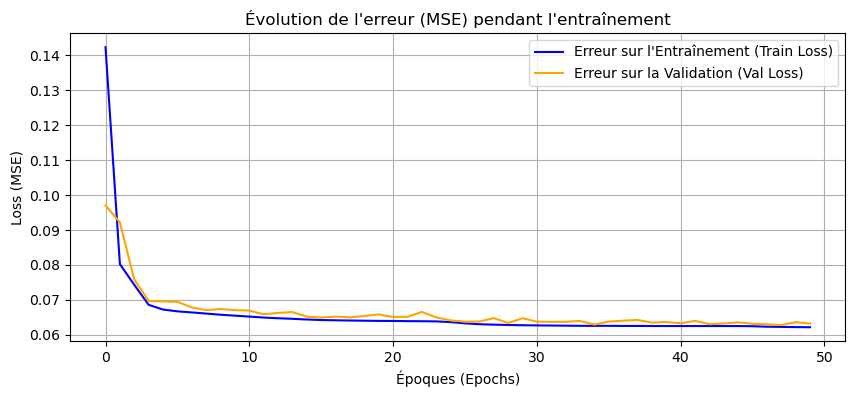

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Erreur sur l\'Entraînement (Train Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Erreur sur la Validation (Val Loss)', color='orange')
plt.title('Évolution de l\'erreur (MSE) pendant l\'entraînement')
plt.xlabel('Époques (Epochs)')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
import plotly.express as px
from tensorflow.keras.models import Model




input_layer = model_simple.layers[0].input

latent_layer_output = model_simple.get_layer("latent_layer").output


encoder = Model(inputs=input_layer, 
                outputs=latent_layer_output)

# 2. Prédire les coordonnées 3D
X_latent = encoder.predict(df_test[features].values)

# 3. Créer un DataFrame pour l'affichage
df_latent = pd.DataFrame(X_latent, columns=['Dim1', 'Dim2', 'Dim3'])
df_latent['session_id'] = df_test['session_id'].values # Pour colorer par session

# 4. Affichage interactif amélioré
fig = px.scatter_3d(
    df_latent, 
    x='Dim1', y='Dim2', z='Dim3',
    color='session_id', 
    title="Espace Latent 3D - Structure Interne",
    opacity=0.3,           # <--- Très important : pour voir la densité
    labels={'Dim1': 'Axe X', 'Dim2': 'Axe Y', 'Dim3': 'Axe Z'}
)

# On réduit la taille des points pour ne pas tout boucher
fig.update_traces(marker=dict(size=2)) # <--- Points plus petits

# On force un ratio égal pour les axes pour éviter les déformations
fig.update_layout(scene=dict(aspectmode='data')) 

fig.show()

1793/1793 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
